In [1]:
import pandas as pd


df = pd.read_parquet("15min_data.parquet")
df = df.rename(columns={"Date": "Datetime"})
df = df.sort_values(["Ticker", "Datetime"])
print(df.head(50))

   Ticker            Datetime      Open      High       Low     Close   Volume
0    AAPL 2019-09-16 09:30:00  54.61750  54.69500  54.39003  54.59250  9712044
1    AAPL 2019-09-16 09:45:00  54.55000  54.95612  54.54250  54.92000  6860892
2    AAPL 2019-09-16 10:00:00  54.92800  54.93250  54.71973  54.74000  4395356
3    AAPL 2019-09-16 10:15:00  54.74000  54.82248  54.58625  54.59750  3583344
4    AAPL 2019-09-16 10:30:00  54.60000  54.74500  54.54750  54.71250  3211824
5    AAPL 2019-09-16 10:45:00  54.71750  54.74750  54.60750  54.72500  2391316
6    AAPL 2019-09-16 11:00:00  54.73125  54.91500  54.72000  54.90425  3380376
7    AAPL 2019-09-16 11:15:00  54.90500  55.02375  54.83000  54.97650  4166960
8    AAPL 2019-09-16 11:30:00  54.97500  55.00750  54.91750  54.99750  3311716
9    AAPL 2019-09-16 11:45:00  54.99750  55.03250  54.72500  54.76250  3973272
10   AAPL 2019-09-16 12:00:00  54.76000  54.83475  54.74500  54.80000  1804100
11   AAPL 2019-09-16 12:15:00  54.79750  54.85000  5

In [2]:
df = df.copy()

cols = ["Open", "High", "Low", "Close", "Volume"]

for col in cols:
    df[f"{col}_perc"] = (
        df.groupby("Ticker")[col]
        .pct_change() * 100
    )

df.head(50)

,Ticker,Datetime,Open,High,Low,Close,Volume,Open_perc,High_perc,Low_perc,Close_perc,Volume_perc
0,AAPL,2019-09-16 09:30:00,54.61750,54.69500,54.39003,54.59250,9712044,NaN,NaN,NaN,NaN,NaN
1,AAPL,2019-09-16 09:45:00,54.55000,54.95612,54.54250,54.92000,6860892,-0.123587,0.477411,0.280327,0.599899,-29.356869
2,AAPL,2019-09-16 10:00:00,54.92800,54.93250,54.71973,54.74000,4395356,0.692942,-0.042980,0.324939,-0.327749,-35.936085
3,AAPL,2019-09-16 10:15:00,54.74000,54.82248,54.58625,54.59750,3583344,-0.342266,-0.200282,-0.243934,-0.260322,-18.474317
4,AAPL,2019-09-16 10:30:00,54.60000,54.74500,54.54750,54.71250,3211824,-0.255754,-0.141329,-0.070989,0.210632,-10.367969
5,AAPL,2019-09-16 10:45:00,54.71750,54.74750,54.60750,54.72500,2391316,0.215201,0.004567,0.109996,0.022847,-25.546481
6,AAPL,2019-09-16 11:00:00,54.73125,54.91500,54.72000,54.90425,3380376,0.025129,0.305950,0.206016,0.327547,41.360489
7,AAPL,2019-09-16 11:15:00,54.90500,55.02375,54.83000,54.97650,4166960,0.317460,0.198033,0.201023,0.131593,23.269127
8,AAPL,2019-09-16 11:30:00,54.97500,55.00750,54.91750,54.99750,3311716,0.127493,-0.029533,0.159584,0.038198,-20.524411
9,AAPL,2019-09-16 11:45:00,54.99750,55.03250,54.72500,54.76250,3973272,0.040928,0.045448,-0.350526,-0.427292,19.976230


# Метрики

In [3]:
import numpy as np
from typing import Union

SeriesLike = Union[pd.Series, np.ndarray, list]


def _to_arrays(y_true: SeriesLike, y_pred: SeriesLike):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    df = pd.concat([y_true, y_pred], axis=1).dropna()
    return df.iloc[:, 0].to_numpy(), df.iloc[:, 1].to_numpy()


# Абосютные ошибки:

def mae(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.mean(np.abs(y_true - y_pred))


def mse(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true: SeriesLike, y_pred: SeriesLike):
    return np.sqrt(mse(y_true, y_pred))


def mdae(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.median(np.abs(y_true - y_pred))


def mdse(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.median((y_true - y_pred) ** 2)


# Относительные ошибки

def mape(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    if np.any(y_true == 0):
        raise ValueError("MAPE неопределён, y_true содержит нули")
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def smape(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    zero_mask = denom == 0
    denom[zero_mask] = np.nan
    return np.nanmean(np.abs(y_true - y_pred) / denom) * 200


def mspe(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    if np.any(y_true == 0):
        raise ValueError("MSPE неопределён, y_true содержит нули")
    return np.mean(((y_true - y_pred) / y_true) ** 2)


def rmspe(y_true: SeriesLike, y_pred: SeriesLike):
    return np.sqrt(mspe(y_true, y_pred))


# Взвешенные ошибки

def wape(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


# Масштабированные метрики

def mase(y_true: SeriesLike, y_pred: SeriesLike, seasonality: int = 1):
    """
    Mean Absolute Scaled Error from Hyndman.
    seasonality = 1 → naive differences (no seasonality)
    seasonality = m → seasonal naive benchmark
    """
    y_true, y_pred = _to_arrays(y_true, y_pred)
    y = pd.Series(y_true)

    if len(y) <= seasonality:
        raise ValueError("Ряд слишком короткий для заданной seasonality")

    scale = np.mean(np.abs(y[seasonality:].to_numpy() - y[:-seasonality].to_numpy()))
    if scale == 0:
        raise ValueError("Scaling factor равен 0; MASE неопределён")

    return np.mean(np.abs(y_true - y_pred)) / scale


def rmsse(y_true: SeriesLike, y_pred: SeriesLike, seasonality: int = 1):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    y = pd.Series(y_true)

    if len(y) <= seasonality:
        raise ValueError("Ряд слишком короткий для заданной RMSSE seasonality")

    scale = np.mean((y[seasonality:].to_numpy() - y[:-seasonality].to_numpy()) ** 2)
    if scale == 0:
        raise ValueError("Scaling factor равен 0; MASE неопределён")

    return np.sqrt(np.mean((y_true - y_pred) ** 2) / scale)


# Относительные оишбки (относительно какой-то baseline-модели)

def rae(y_true: SeriesLike, y_pred: SeriesLike, y_baseline: SeriesLike):
    """Relative Absolute Error."""
    y_true, y_pred = _to_arrays(y_true, y_pred)
    y_true_b, y_base = _to_arrays(y_true, y_baseline)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true_b - y_base))


def rse(y_true: SeriesLike, y_pred: SeriesLike, y_baseline: SeriesLike):
    """Relative Squared Error."""
    y_true, y_pred = _to_arrays(y_true, y_pred)
    y_true_b, y_base = _to_arrays(y_true, y_baseline)
    return np.sum((y_true - y_pred) ** 2) / np.sum((y_true_b - y_base) ** 2)


def rmae(y_true: SeriesLike, y_pred: SeriesLike, y_baseline: SeriesLike):
    return rae(y_true, y_pred, y_baseline)


def rrmse(y_true: SeriesLike, y_pred: SeriesLike, y_baseline: SeriesLike):
    return np.sqrt(rse(y_true, y_pred, y_baseline))


# Нормализованные метрики

def nrmse_std(y_true: SeriesLike, y_pred: SeriesLike):
    """Normalize RMSE by standard deviation of y_true."""
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return rmse(y_true, y_pred) / np.std(y_true)


def nmae_range(y_true: SeriesLike, y_pred: SeriesLike):
    """Normalize MAE by value range."""
    y_true, y_pred = _to_arrays(y_true, y_pred)
    rng = np.max(y_true) - np.min(y_true)
    if rng == 0:
        raise ValueError("Range равен 0; NMAE неопределён")
    return mae(y_true, y_pred) / rng

# Прогнозы временных рядов с помощью классических методов

In [11]:
def prepare_data(df, ticker, target_col="target", datetime_col="Datetime"):
    """
    Фильтрует данные по тикеру, сортирует по времени и создаёт числовой временной индекс.
    """
    df = df[df["Ticker"] == ticker].copy()

    # Приведение к datetime и сортировка
    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df = df.sort_values(datetime_col).reset_index(drop=True)

    # Порядковый индекс времени
    df["time_idx"] = np.arange(len(df))

    return df[[datetime_col, "time_idx", target_col]].reset_index(drop=True)

amzn = prepare_data(df, 'AMZN', target_col="Close_perc")
amzn.tail()

,Datetime,time_idx,Close_perc
40070,2025-11-07 14:45:00,40070,0.174807
40071,2025-11-07 15:00:00,40071,0.065699
40072,2025-11-07 15:15:00,40072,-0.139514
40073,2025-11-07 15:30:00,40073,0.579365
40074,2025-11-07 15:45:00,40074,-0.151156


Посмотрим на стационарность:

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

def check_stationarity(
    df: pd.DataFrame,
    target_cols: list = None,
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Запускает два теста стационарности: ADF и KPSS.
    Возвращает те же поля, что и раньше, просто два теста подряд.
    """

    time_col = "Datetime" if "Datetime" in df.columns else "Date"
    df[time_col] = pd.to_datetime(df[time_col])

    # авто-поиск числовых колонок
    if not target_cols:
        exclude_cols = [time_col, "Ticker"]
        target_cols = [
            col for col in df.columns
            if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])
        ]

    results = []

    for ticker, group in df.groupby("Ticker"):
        group = group.sort_values(time_col)

        for col in target_cols:
            series = group[col].dropna()

            if len(series) < 10:
                continue

            # --------------------
            # ADF
            # --------------------
            adf_stat, adf_p, _, _, _, _ = adfuller(series)
            adf_stationary = int(adf_p < alpha)  # H0: нестационарен

            results.append({
                "Ticker": ticker,
                "Feature": col,
                "Test": "ADF",
                "TestStatistic": adf_stat,
                "PValue": adf_p,
                "IsStationary": adf_stationary
            })

            # --------------------
            # KPSS
            # --------------------
            kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")
            kpss_stationary = int(kpss_p > alpha)  # H0: стационарен

            results.append({
                "Ticker": ticker,
                "Feature": col,
                "Test": "KPSS",
                "TestStatistic": kpss_stat,
                "PValue": kpss_p,
                "IsStationary": kpss_stationary
            })

    return pd.DataFrame(results)


stationarity_results = check_stationarity(df[df['Ticker'] == 'AMZN'])

/tmp/ipython-input-59818751.py:54: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")
/tmp/ipython-input-59818751.py:54: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")
/tmp/ipython-input-59818751.py:54: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")
/tmp/ipython-input-59818751.py:54: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than th

In [ ]:
stationarity_results

,Ticker,Feature,Test,TestStatistic,PValue,IsStationary
0,AMZN,Open,ADF,-1.183085,6.808295e-01,0
1,AMZN,Open,KPSS,13.417951,1.000000e-02,0
2,AMZN,High,ADF,-1.111627,7.104129e-01,0
3,AMZN,High,KPSS,13.431592,1.000000e-02,0
4,AMZN,Low,ADF,-1.138677,6.994042e-01,0
5,AMZN,Low,KPSS,13.410724,1.000000e-02,0
6,AMZN,Close,ADF,-1.197729,6.745718e-01,0
7,AMZN,Close,KPSS,13.420539,1.000000e-02,0
8,AMZN,Volume,ADF,-14.111964,2.510668e-26,1
9,AMZN,Volume,KPSS,9.576257,1.000000e-02,0


### Простые прогнозы на основе классических методов:

In [7]:
def naive_forecast(series, horizon):
    # Наивный метод y^​t+1​=yt​
    last_value = series.iloc[-1]
    return np.repeat(last_value, horizon)


def seasonal_naive_forecast(series, horizon, season_length=7):
    """
    season_length = 26 - дневная сезонность
    """
    values = series.iloc[-season_length:]
    repeats = horizon // season_length + 1
    return np.tile(values, repeats)[:horizon]


def moving_average_forecast(series, horizon, window=26, mode="shift"):
    """
    Реально рекурсивный вариант Moving Average:
    mode = "shift"     → фиксированное окно
    mode = "expanding" → растущее окно
    """

    history = list(series)
    forecasts = []

    for i in range(horizon):

        if mode == "shift":
            current_window = window

        elif mode == "expanding":
            current_window = window + i

        else:
            raise ValueError("mode должен быть 'shift' или 'expanding'.")

        # ограничиваем окно длиной истории
        current_window = min(current_window, len(history))

        # среднее по окну
        ma = np.mean(history[-current_window:])

        # записываем прогноз
        forecasts.append(ma)

        # рекурсивность: добавляем прогноз в историю
        history.append(ma)

    return np.array(forecasts)



def drift_forecast(series, horizon, lookback=None):
    """
    lookback: если None - используем всю выборку, иначе используем последние lookback точек
    """
    if lookback is not None:
        series = series.iloc[-lookback:]

    y1 = series.iloc[0]
    y_last = series.iloc[-1]
    n = len(series)

    drift = (y_last - y1) / (n - 1)
    return y_last + drift * np.arange(1, horizon + 1)


from statsmodels.tsa.holtwinters import ExponentialSmoothing


def exponential_smoothing_forecast(
    series,
    horizon,
    trend=None,            # None, 'add', 'mul'
    damped=False,          # демпфирование тренда
    seasonal=None,         # None, 'add', 'mul'
    seasonal_periods=None, # период сезонности
    use_boxcox=False,      # Box-Cox преобразование
    initialization_method="estimated",  # 'estimated' или 'heuristic'
    optimized=True,        # авто-поиск параметров
    smoothing_level=None,  # α
    smoothing_slope=None,  # β
    smoothing_seasonal=None, # γ
    damping_slope=None      # φ
):

    model = ExponentialSmoothing(
        series,
        trend=trend, # 'add', 'mul' или None
        damped_trend=damped, # True / False
        seasonal=seasonal, # 'add', 'mul' или None
        seasonal_periods=seasonal_periods,
        initialization_method=initialization_method,
        use_boxcox=use_boxcox,
    )

    fitted = model.fit(
        optimized=optimized,
        smoothing_level=smoothing_level,
        smoothing_slope=smoothing_slope,
        smoothing_seasonal=smoothing_seasonal,
        damping_slope=damping_slope,
    )

    forecast = fitted.forecast(horizon)
    return forecast, fitted

In [8]:
import numpy as np
import pandas as pd
import lightgbm as lgb


def make_features(series, lags, rolling_windows=(7, 14, 28)):
    df = pd.DataFrame({"y": series})

    # лаги
    for lag in lags:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # rolling mean
    for w in rolling_windows:
        df[f"rolling_mean_{w}"] = df["y"].shift(1).rolling(w).mean()
        df[f"rolling_std_{w}"] = df["y"].shift(1).rolling(w).std()
        df[f"rolling_min_{w}"] = df["y"].shift(1).rolling(w).min()
        df[f"rolling_max_{w}"] = df["y"].shift(1).rolling(w).max()

    df = df.dropna()
    return df


def lgb_forecast(
    series,
    horizon,
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28),
    n_estimators=100,
    learning_rate=0.05,
    max_depth=-1
):

    # --- фичи ---
    df = make_features(series, lags, rolling_windows)

    X = df.drop(columns=["y"])
    y = df["y"]

    # -модель ---
    model = lgb.LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_jobs=-1
    )
    model.fit(X, y)

    # рекурсивный прогноз
    history = list(series)
    preds = []

    for _ in range(horizon):

        features = {}

        # лаги
        for lag in lags:
            features[f"lag_{lag}"] = history[-lag] if lag <= len(history) else history[0]

        # rolling
        for w in rolling_windows:
            window = history[-w:] if len(history) >= w else history

            features[f"rolling_mean_{w}"] = np.mean(window)
            features[f"rolling_std_{w}"] = np.std(window)
            features[f"rolling_min_{w}"] = np.min(window)
            features[f"rolling_max_{w}"] = np.max(window)

        X_pred = np.array(list(features.values())).reshape(1, -1)

        pred = model.predict(X_pred)[0]

        preds.append(pred)
        history.append(pred)

    return np.array(preds), model

In [ ]:
pip install prophet

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 34494, number of used features: 18
[LightGBM] [Info] Start training from score 0.003499


Выходные данные были обрезаны до нескольких последних строк (5000).
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  wa

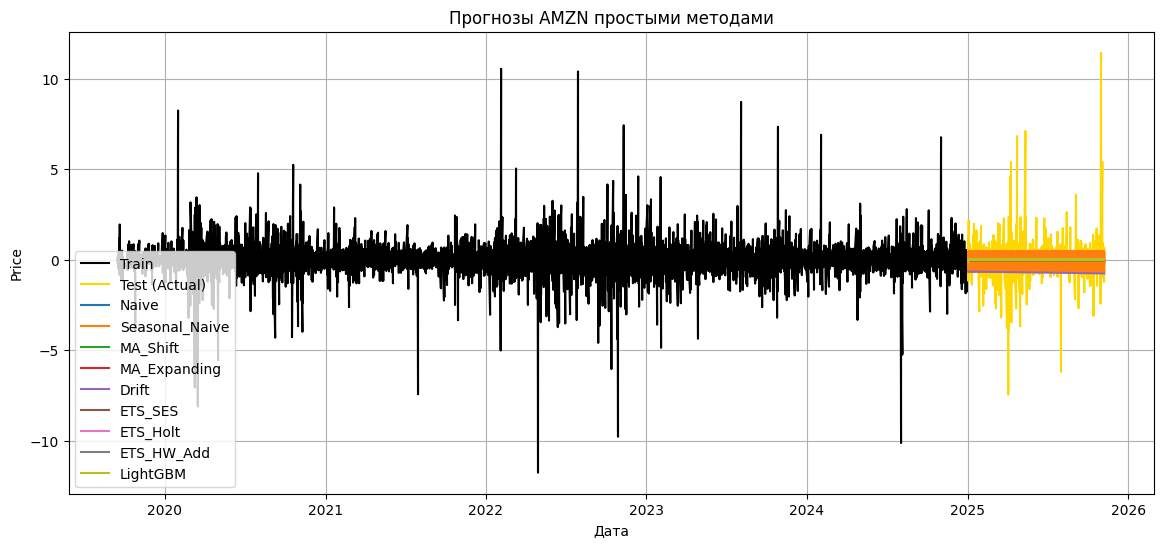

In [14]:
import matplotlib.pyplot as plt


def train_test_split_by_date(
    df,
    date_col="Datetime",
    split_date="2025-01-01",
    dropna=True
):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    if dropna:
        df = df.dropna()

    train = df[df[date_col] < split_date]
    test  = df[df[date_col] >= split_date]

    return train, test


# Делаем split
train, test = train_test_split_by_date(amzn, "Datetime", "2025-01-01")

y_train = train["Close_perc"]
horizon = len(test)

# Запуск всех методов
preds = pd.DataFrame({
    "Datetime": test["Datetime"].values,
    "Actual": test["Close_perc"].values
})

# 1. Naive
preds["Naive"] = naive_forecast(y_train, horizon)

# 2. Seasonal Naive
preds["Seasonal_Naive"] = seasonal_naive_forecast(y_train, horizon, season_length=26)

# 3. Moving Average (shift)
preds["MA_Shift"] = moving_average_forecast(y_train, horizon, window=120, mode="shift")

# 4. Moving Average (expanding)
preds["MA_Expanding"] = moving_average_forecast(y_train, horizon, window=120, mode="expanding")

# 5. Drift
preds["Drift"] = drift_forecast(y_train, horizon)

# 6. ETS Models

# SES (ETS(A,N,N))
preds["ETS_SES"] = exponential_smoothing_forecast(
    y_train, horizon, trend=None, seasonal=None
)[0].values

# Holt (ETS(A,A,N))
preds["ETS_Holt"] = exponential_smoothing_forecast(
    y_train, horizon, trend="add", seasonal=None
)[0].values

# Holt-Winters ADDITIVE (ETS(A,A,A))
preds["ETS_HW_Add"] = exponential_smoothing_forecast(
    y_train, horizon,
    trend="add",
    seasonal="add",
    seasonal_periods=26
)[0].values


# 7. LightGBM (lags + rolling)
lgb_preds, lgb_model = lgb_forecast(
    y_train,
    horizon,
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28),
    n_estimators=200,
    learning_rate=0.05
)

preds["LightGBM"] = lgb_preds


# Визуализация

plt.figure(figsize=(14, 6))
plt.plot(train["Datetime"], y_train, label="Train", color="black")
plt.plot(test["Datetime"], test["Close_perc"], label="Test (Actual)", color="gold")

for col in preds.columns:
    if col not in ("Datetime", "Actual"):
        plt.plot(preds["Datetime"], preds[col], label=col)

plt.title("Прогнозы AMZN простыми методами")
plt.xlabel("Дата")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


naive_methods = preds.copy()  # Сохраним для дальнейшего анализа

In [18]:
import plotly.graph_objects as go

def plot_forecasts_interactive(train, test, preds, target_col="Close_perc"):
    """
    train — DataFrame с тренингом (Datetime, Close)
    test — DataFrame с тестом
    preds — DataFrame: Datetime, Actual, Model1, Model2, ...
    """

    fig = go.Figure()


    fig.add_trace(go.Scatter(
        x=train["Datetime"],
        y=train[target_col],
        mode="lines",
        name="Train",
        line=dict(color="black", width=2)
    ))

    fig.add_trace(go.Scatter(
        x=test["Datetime"],
        y=test[target_col],
        mode="lines",
        name="Test (Actual)",
        line=dict(color="gold", width=3)
    ))

    # Прогнозы
    for col in preds.columns:
        if col in ("Datetime", "Actual"):
            continue

        fig.add_trace(go.Scatter(
            x=preds["Datetime"],
            y=preds[col],
            mode="lines",
            name=col,
            line=dict(width=2),
            visible="legendonly"   # скрыты по умолчанию
        ))

    fig.update_layout(
        title="Прогнозы Close_perc AMZN на 2025 год — интерактивная визуализация",
        xaxis_title="Дата",
        yaxis_title="Цена",
        width=1200,
        height=600,
        template="plotly_white",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )

    fig.show()


plot_forecasts_interactive(train, test, preds, target_col="Close_perc")

In [19]:
naive_methods.head()

,Datetime,Actual,Naive,Seasonal_Naive,MA_Shift,MA_Expanding,Drift,ETS_SES,ETS_Holt,ETS_HW_Add,LightGBM
0,2025-01-02 09:30:00,0.793108,-0.647591,0.013562,-0.020778,-0.020778,-0.647610,0.00349,0.00364,-0.000777,0.019765
1,2025-01-02 09:45:00,1.309180,-0.647591,0.467809,-0.029448,-0.020778,-0.647629,0.00349,0.00364,0.002473,-0.003818
2,2025-01-02 10:00:00,0.372731,-0.647591,-0.281134,-0.033450,-0.020778,-0.647648,0.00349,0.00364,-0.018504,-0.086495
3,2025-01-02 10:15:00,-0.714262,-0.647591,-0.113057,-0.031558,-0.020778,-0.647667,0.00349,0.00364,0.006818,-0.014737
4,2025-01-02 10:30:00,-0.516855,-0.647591,-0.076563,-0.032459,-0.020778,-0.647687,0.00349,0.00364,0.018492,-0.005878


In [22]:
naive_methods.head()

,Datetime,Actual,Naive,Seasonal_Naive,MA_Shift,MA_Expanding,Drift,ETS_SES,ETS_Holt,ETS_HW_Add,LightGBM
0,2025-01-02 09:30:00,0.793108,-0.647591,0.013562,-0.020778,-0.020778,-0.647610,0.00349,0.00364,-0.000777,0.019765
1,2025-01-02 09:45:00,1.309180,-0.647591,0.467809,-0.029448,-0.020778,-0.647629,0.00349,0.00364,0.002473,-0.003818
2,2025-01-02 10:00:00,0.372731,-0.647591,-0.281134,-0.033450,-0.020778,-0.647648,0.00349,0.00364,-0.018504,-0.086495
3,2025-01-02 10:15:00,-0.714262,-0.647591,-0.113057,-0.031558,-0.020778,-0.647667,0.00349,0.00364,0.006818,-0.014737
4,2025-01-02 10:30:00,-0.516855,-0.647591,-0.076563,-0.032459,-0.020778,-0.647687,0.00349,0.00364,0.018492,-0.005878


In [27]:
def evaluate_all_models(merged, target="Actual", baseline="Naive"):
    models = [col for col in merged.columns if col not in ("Datetime", target)]

    results = []

    for model in models:
        y_true = merged[target]
        y_pred = merged[model]
        y_base = merged[baseline]

        row = {
            "Model": model,

            # Асболютные ошибки
            "MAE": mae(y_true, y_pred),
            "MSE": mse(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "MDAE": mdae(y_true, y_pred),
            "MDSE": mdse(y_true, y_pred),

            # Относительные ошибки
            "MAPE": mape(y_true, y_pred),
            "sMAPE": smape(y_true, y_pred),
            "MSPE": mspe(y_true, y_pred),
            "RMSPE": rmspe(y_true, y_pred),

            # Взвешанные
            "WAPE": wape(y_true, y_pred),

            # Нормализованные метрики
            "MASE": mase(y_true, y_pred, seasonality=1),
            "RMSSE": rmsse(y_true, y_pred, seasonality=1),

            # Относительно baseline (Naive)
            "RAE": rae(y_true, y_pred, y_base),
            "RSE": rse(y_true, y_pred, y_base),
            "RMAE": rmae(y_true, y_pred, y_base),
            "RRMSE": rrmse(y_true, y_pred, y_base),

            # Normalized
            "NRMSE_STD": nrmse_std(y_true, y_pred),
            "NMAE_RANGE": nmae_range(y_true, y_pred)
        }

        results.append(row)

    return pd.DataFrame(results)


metrics_df = evaluate_all_models(naive_methods[naive_methods['Actual'] != 0].copy(), target="Actual", baseline="Naive")
metrics_df

,Model,MAE,MSE,RMSE,MDAE,MDSE,MAPE,sMAPE,MSPE,RMSPE,WAPE,MASE,RMSSE,RAE,RSE,RMAE,RRMSE,NRMSE_STD,NMAE_RANGE
0,Naive,0.687491,0.644571,0.802852,0.653779,0.427427,2298.266361,160.254388,122129.772331,349.470703,2.873891,1.941884,1.200877,1.004635,1.004032,1.004635,1.002014,1.706900,0.036421
1,Seasonal_Naive,0.335406,0.291578,0.539980,0.249592,0.062296,627.103130,149.608493,6259.373743,79.116204,1.402084,0.947386,0.807683,0.490131,0.454184,0.490131,0.673932,1.148022,0.017768
2,MA_Shift,0.241314,0.222476,0.471673,0.144940,0.021008,178.825236,159.386677,303.550754,17.422708,1.008757,0.681616,0.705512,0.352634,0.346545,0.352634,0.588680,1.002799,0.012784
3,MA_Expanding,0.240131,0.221803,0.470960,0.144193,0.020792,147.532805,167.722556,126.955903,11.267471,1.003812,0.678274,0.704445,0.350906,0.345497,0.350906,0.587790,1.001283,0.012721
4,Drift,0.738139,0.717809,0.847236,0.710645,0.505016,2537.993521,161.988770,155813.822130,394.732596,3.085611,2.084943,1.267265,1.078647,1.118112,1.078647,1.057408,1.801263,0.039104
5,ETS_SES,0.239219,0.221236,0.470357,0.144505,0.020882,105.692556,190.010949,4.507350,2.123052,0.999997,0.675696,0.703543,0.349572,0.344613,0.349572,0.587038,1.000000,0.012673
6,ETS_Holt,0.239220,0.221236,0.470357,0.144614,0.020913,106.058815,189.623303,4.908776,2.215576,1.000000,0.675699,0.703543,0.349573,0.344613,0.349573,0.587038,1.000001,0.012673
7,ETS_HW_Add,0.239363,0.221332,0.470459,0.144472,0.020872,112.904053,182.504695,13.442811,3.666444,1.000601,0.676105,0.703696,0.349783,0.344763,0.349783,0.587166,1.000219,0.012681
8,LightGBM,0.242212,0.222737,0.471951,0.148361,0.022011,196.741346,157.509855,443.873278,21.068300,1.012507,0.684150,0.705927,0.353945,0.346952,0.353945,0.589027,1.003389,0.012831




*   На данном этапе задачей было добавить метод градиентного бустинга для прогнозирвоания временных рядов. Удалось успешно решить эту задачу, добавим лаговые и скользящие признаки на основе таргетной колонки (выбранная модель - lightGDM), успешно добавлена в структуру нашего репозитория через fatsapi. Теперь сервис позволяет прогнозировать не только с помощью классических методов, а также с помощью методов машинного обучения
*   Добавлена возможность прогнозирования не самих значений признаков, а их процентного изменения, так как такое прогнозирование является более осмысленным

lightGDM по точности сравним с основными методами наивного прогноза (в частности, с семейством ETS)
